In [1]:
import os
os.environ["WORLD_SIZE"] = "1"
os.environ["RANK"] = "0"
os.environ["LOCAL_RANK"] = "0"
os.environ["MASTER_ADDR"] = "localhost"
os.environ["MASTER_PORT"] = "12355"

# Volume Benchmarking of External Aero Flows

In this notebook, we walk through the steps required to generate a sample model inference on a simulation mesh and compare the model's predictions with ground-truth data across several metrics relevant to external aerodynamics. This notebook uses the volume results from the [DrivAerML dataset](https://caemldatasets.org/drivaerml/). Specifically, we use sample ID `202` to compute all metrics and comparisons.

## Prerequisites

For running this notebook, ensure that you have installed the library using `[gpu]` optional dependency group. This can be done using:

```bash
pip install .[gpu] --extra-index-url=https://pypi.nvidia.com
```

## Compute model inference on the benchmark simulation

The benchmark results are saved in `.vtp` (surface) and `.vtu` (volume) formats. For this notebook, let's start by loading the `.vtu` file and inspecting the available fields. We will use the `pyvista` library for this purpose.

---
**NOTE**

The volume files in the DrivAerML dataset are large (each file is ~38 GB). Ensure you have sufficient memory to load them.

---

### Download the benchmark solution

Let's download the solution from the [DrivAerML dataset](https://huggingface.co/datasets/neashton/drivaerml).

In [2]:
import os

filenames = [
    "drivaer_202.stl",
    "volume_202.vtu.00.part",
    "volume_202.vtu.01.part",
]
urls = [
    "https://huggingface.co/datasets/neashton/drivaerml/resolve/main/run_202/drivaer_202.stl",
    "https://huggingface.co/datasets/neashton/drivaerml/resolve/main/run_202/volume_202.vtu.00.part",
    "https://huggingface.co/datasets/neashton/drivaerml/resolve/main/run_202/volume_202.vtu.01.part",
]

for filename, url in zip(filenames, urls):
    if not os.path.exists(filename):
        !wget --quiet "{url}" -O "{filename}"
    else:
        print(f"{filename} already exists. Skipping download.")

if not os.path.exists("volume_202.vtu"):
    !cat "volume_202.vtu.00.part" "volume_202.vtu.01.part" > "volume_202.vtu"

drivaer_202.stl already exists. Skipping download.
volume_202.vtu.00.part already exists. Skipping download.
volume_202.vtu.01.part already exists. Skipping download.


In [3]:
import pyvista as pv

mesh = pv.read("./volume_202.vtu")
mesh

UnstructuredGrid (0x7fffb63061a0)
  N Cells:    146754704
  N Points:   165122607
  X Bounds:   -4.000e+01, 8.000e+01
  Y Bounds:   -2.200e+01, 2.200e+01
  Z Bounds:   -3.176e-01, 1.968e+01
  N Arrays:   21

We observe that the mesh contains `165,122,607` points and `146,754,704` cells. The pressure, velocity, and turbulent viscosity variables are stored as `pMeanTrim`, `UMeanTrim`, and `nutMeanTrim`, respectively. We'll denote the model's predictions as `pMeanTrimPred`, `UMeanTrimPred`, and `nutMeanTrimPred`. We compute the inference using the DoMINO model wrapper with a pretrained checkpoint. Unlike the surface notebook, we will perform all computations on point data, and we will store model results on point data as well. You can adapt the code to your specific model inputs/outputs.

---

In [4]:
import numpy as np
import time
from physicsnemo.cfd.evaluation.models.wrappers.domino.wrapper import DominoWrapper
from physicsnemo.cfd.evaluation.datasets.schema import CanonicalCase

CHECKPOINT_DIR = "/lustre/fsw/coreai_modulus_cae/ktangsali/aero-benchmarking/physicsnemo-external-aero-checkpoints/domino_drivaerml_checkpoint"

wrapper = DominoWrapper()
wrapper.load(
    checkpoint_path=f"{CHECKPOINT_DIR}/volume/DoMINO.0.615.mdlus",
    stats_path="",
    device="cuda:0",
    domino_config=f"{CHECKPOINT_DIR}/config_volume.yaml",
)

case = CanonicalCase(
    case_id="run_202",
    mesh_path="./volume_202.vtu",
    mesh_type="point",
    inference_domain="volume",
)

start_time = time.time()
model_input = wrapper.prepare_inputs(case)
raw_output = wrapper.predict(model_input)
predictions = wrapper.decode_outputs(raw_output, case)

mesh.point_data["pMeanTrimPred"] = predictions["pressure"]
mesh.point_data["UMeanTrimPred"] = predictions["velocity"]
mesh.point_data["nutMeanTrimPred"] = predictions["turbulent_viscosity"]
print(f"Inference took {time.time() - start_time:.3f} sec")

bounds = [-3.5, 8.5, -2.25, 2.25, -0.32, 3.00]

mesh

/workspace/aero-benchmarking/physicsnemo/physicsnemo/nn/functional/interpolation/_torch_impl.py:69: SyntaxWarning: invalid escape sequence '\('
  """
/workspace/aero-benchmarking/physicsnemo/physicsnemo/nn/functional/interpolation/_torch_impl.py:92: SyntaxWarning: invalid escape sequence '\('
  """


Warp DeprecationWarning: The namespace `warp.context` will soon be removed from the public API. It can still be accessed from `warp._src.context` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/usr/local/lib/python3.12/dist-packages/torch/library.py:357: UserWarning: Warning only once for all operators,  other operators may also be overridden.
  Overriding a previously registered kernel for the same operator and the same dispatch key
  operator: flash_attn::_flash_attn_backward(Tensor dout, Tensor q, Tensor k, Tensor v, Tensor out, Tensor softmax_lse, Tensor(a6!)? dq, Tensor(a7!)? dk, Tensor(a8!)? dv, float dropout_p, float softmax_scale, bool causal, SymInt window_size_left, SymInt window_size_right, float softcap, Tensor? alibi_slopes, bool deterministic, Tensor? rng_state=None) -> Tensor
    registered at /usr/local/lib/python3.12/dist-packages/torch/_library/custom_ops.py:926
  dispatch key: ADInplaceOrView
  previous kernel: no debug info
       new kernel: registered at /usr/local/lib/python3.12/dist-packages/torch/_library/custom_ops.py:926 (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/core/dispatch/OperatorEntry.cpp:208.)
  self.m.impl(
/workspace/aero-

/workspace/aero-benchmarking/physicsnemo-cfd/physicsnemo/cfd/evaluation/models/wrappers/geotransolver/wrapper.py:57: ExperimentalFeatureWarning: You are importing from 'physicsnemo.experimental'. The APIs in this namespace are experimental, under active development, and may change without notice. Expect possible back-compatibility breaking changes and only partial test coverage.
  from physicsnemo.experimental.models.geotransolver import GeoTransolver


...

[inference:domino] Reading case inputs (case run_202): mesh ./volume_202.vtu, run dir .


[inference:domino] Running forward pass (predicting volume fields)…


[inference:domino] Decoding volume outputs (canonical keys from variables.volume.solution)…


Inference took 493.826 sec


UnstructuredGrid (0x7fffb63061a0)
  N Cells:    146754704
  N Points:   165122607
  X Bounds:   -4.000e+01, 8.000e+01
  Y Bounds:   -2.200e+01, 2.200e+01
  Z Bounds:   -3.176e-01, 1.968e+01
  N Arrays:   24

Now that we have both the predicted and true fields on the same points, we can start comparing these two solutions.

## L2 Errors

Let's compare the L2 errors for the pressure, velocity, and turbulent viscosity fields using the library function `compute_l2_errors`. We pass the `bounds` argument to restrict the computation to the region where model results are available.

In [5]:
from physicsnemo.cfd.postprocessing_tools.metrics.l2_errors import compute_l2_errors

l2_errors = compute_l2_errors(
    mesh,
    true_fields=["pMeanTrim", "UMeanTrim"],
    pred_fields=["pMeanTrimPred", "UMeanTrimPred"],
    bounds=[-3.5, 8.5, -2.25, 2.25, -0.32, 3.00],
    dtype="point",
)
l2_errors

{'pMeanTrim_l2_error': 0.10848417,
 'UMeanTrim_x_l2_error': 0.08351647,
 'UMeanTrim_y_l2_error': 0.18684481,
 'UMeanTrim_z_l2_error': 0.19030663}

L2 errors provide an aggregate sense of model performance, but they do not reveal the distribution of errors. Below, we compute the distribution of absolute errors as a function of distance from the STL.

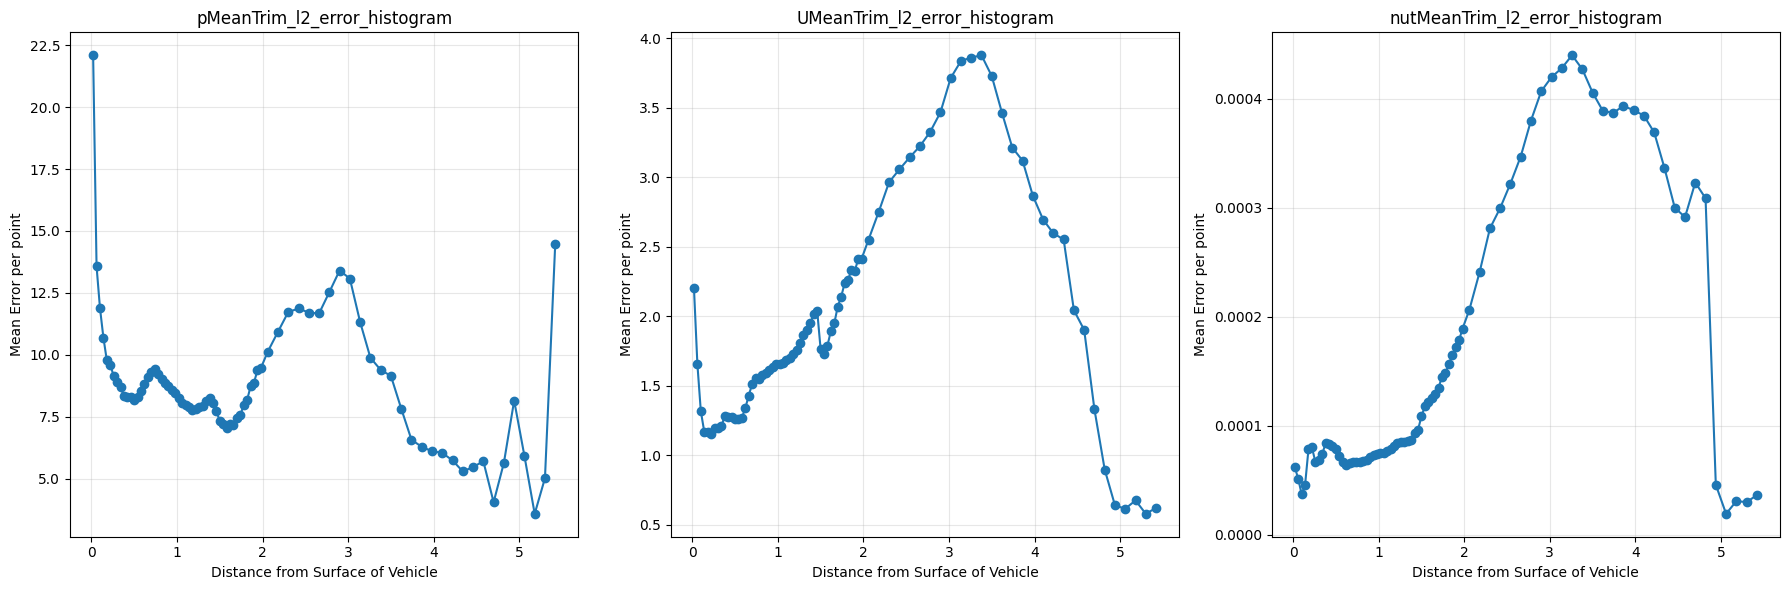

In [6]:
from physicsnemo.cfd.postprocessing_tools.metrics.l2_errors import compute_error_vs_sdf
import matplotlib.pyplot as plt

# determine query points for sdf
bin_edges = np.linspace(0, 2, 50, endpoint=False)
bin_edges = np.concatenate([bin_edges, np.linspace(2, 8, 51)])

stl_mesh = pv.read("./drivaer_202.stl")

output_dict = compute_error_vs_sdf(
    mesh,
    ["pMeanTrim", "UMeanTrim", "nutMeanTrim"],
    ["pMeanTrimPred", "UMeanTrimPred", "nutMeanTrimPred"],
    stl_mesh,
    bin_edges,
    bounds=[-3.5, 8.5, -2.25, 2.25, -0.32, 3.00],
    dtype="point",
    device="cuda",
)
# print(output_dict)
keys_to_plot = [key for key in output_dict.keys() if "histogram" in key]
fig, axs = plt.subplots(1, len(keys_to_plot), figsize=(18,6))
for i, key in enumerate(keys_to_plot):
    ax = axs[i]
    bin_centers = output_dict[key]["bin_edges"]
    bin_centers = [(a + b) / 2 for a, b in zip(bin_centers, bin_centers[1:])]
    errors = output_dict[key]["mean_errors"]
    ax.plot(bin_centers, errors, marker='o')
    ax.set_title(key)
    ax.set_xlabel('Distance from Surface of Vehicle')
    ax.set_ylabel('Mean Error per point')
    ax.grid(True, alpha=0.3)
plt.tight_layout()

We observe that for pressure and velocity, error is higher near the STL surface, while for turbulent viscosity the trend is reversed. This can inform model architecture or loss weighting choices. Below, we show this distribution computed across the entire DrivAerML validation dataset.

![Aggregate Error as a function of SDF](img/error_vs_sdf.png)


## Plotting fields

Much of volumetric data analysis relies on visualizing the flow field for specific features of interest. Let's create a few slices and use `plot_field_comparisons` to generate visuals.


In [7]:
# Create a slice that runs along the centerline
y_slice = mesh.slice(normal="y", origin=(0, 0, 0))
y_slice = y_slice.clip_box(bounds, invert=False)

# Create a slice to visualize the wake of the car
x_4_slice = mesh.slice(normal="x", origin=(4, 0, 0))
x_4_slice = x_4_slice.clip_box(bounds, invert=False)

# Create a slice normal to z axis to visualize the wheel wakes
z_neg_0_2376_slice = mesh.slice(normal="z", origin=(0, 0, -0.2376))
z_neg_0_2376_slice = z_neg_0_2376_slice.clip_box(bounds, invert=False)

2026-04-10 11:18:47.642 (2997.005s) [    7FFFF7C73540]      vtkPolyhedron.cxx:2025  WARN| A cell with a non-manifold triangulation has been encountered. This cell cannot be contoured.
2026-04-10 11:18:47.844 (2997.208s) [    7FFFF7C73540]      vtkPolyhedron.cxx:2025  WARN| A cell with a non-manifold triangulation has been encountered. This cell cannot be contoured.
2026-04-10 11:18:58.234 (3007.597s) [    7FFFF7C73540]      vtkPolyhedron.cxx:2025  WARN| A cell with a non-manifold triangulation has been encountered. This cell cannot be contoured.
2026-04-10 11:18:58.565 (3007.929s) [    7FFFF7C73540]      vtkPolyhedron.cxx:2025  WARN| A cell with a non-manifold triangulation has been encountered. This cell cannot be contoured.
2026-04-10 11:19:15.461 (3024.825s) [    7FFFF7C73540]      vtkPolyhedron.cxx:2025  WARN| A cell with a non-manifold triangulation has been encountered. This cell cannot be contoured.
2026-04-10 11:19:22.654 (3032.018s) [    7FFFF7C73540]      vtkPolyhedron.cxx:20

/workspace/aero-benchmarking/physicsnemo-cfd/physicsnemo/cfd/postprocessing_tools/visualization/utils.py:26: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk with osmesa instead.
  pv.start_xvfb()


/tmp/ipykernel_1583154/306130833.py:3: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk with osmesa instead.
  pv.start_xvfb()


2026-04-10 11:20:17.934 (3087.297s) [    7FFFF7C73540]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library
2026-04-10 11:20:18.006 (3087.370s) [    7FFFF7C73540]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library


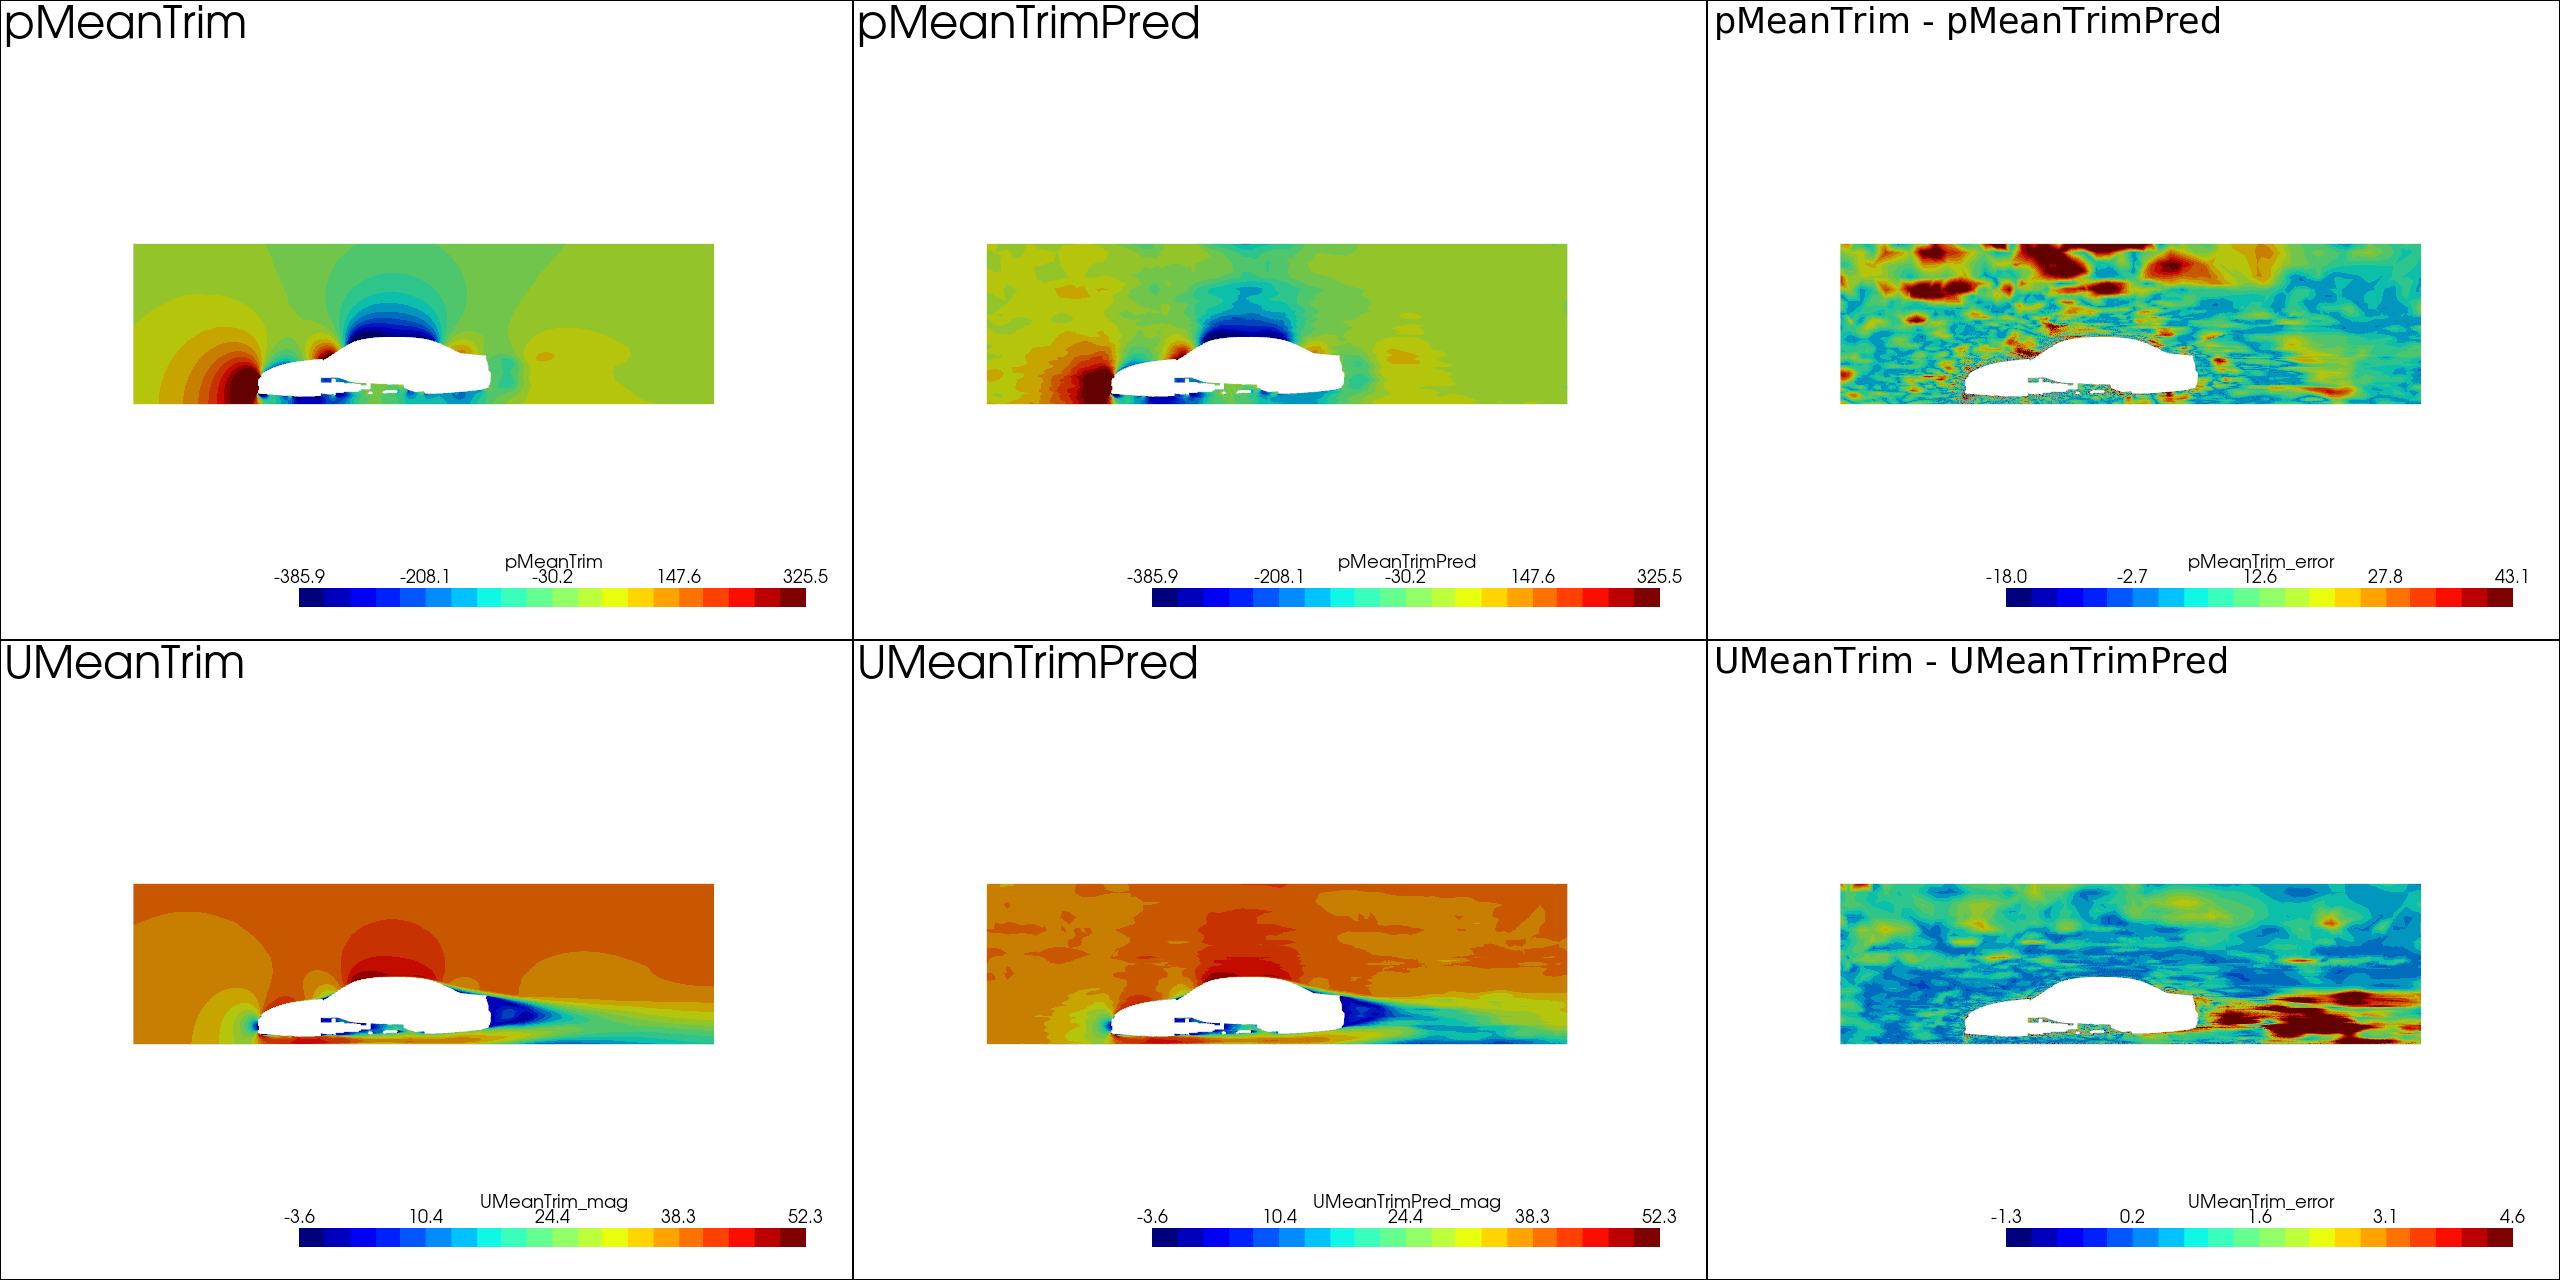

In [8]:
from physicsnemo.cfd.postprocessing_tools.visualization.utils import plot_field_comparisons

_xvfb = getattr(pv, "start_xvfb", None)
if _xvfb is not None:
    _xvfb()
else:
    pv.OFF_SCREEN = True

plotter = plot_field_comparisons(
    y_slice,
    true_fields=["pMeanTrim", "UMeanTrim"],
    pred_fields=["pMeanTrimPred", "UMeanTrimPred"],
    plot_vector_components=False,
    view="xz",
    dtype="point",
    cmap="jet",
    lut=20,
    window_size=[2560, 1280],
)

plotter.screenshot("./sample_202_volume_y_slice_comparison.png")

# Display the image
from IPython.display import Image

Image(filename="./sample_202_volume_y_slice_comparison.png")

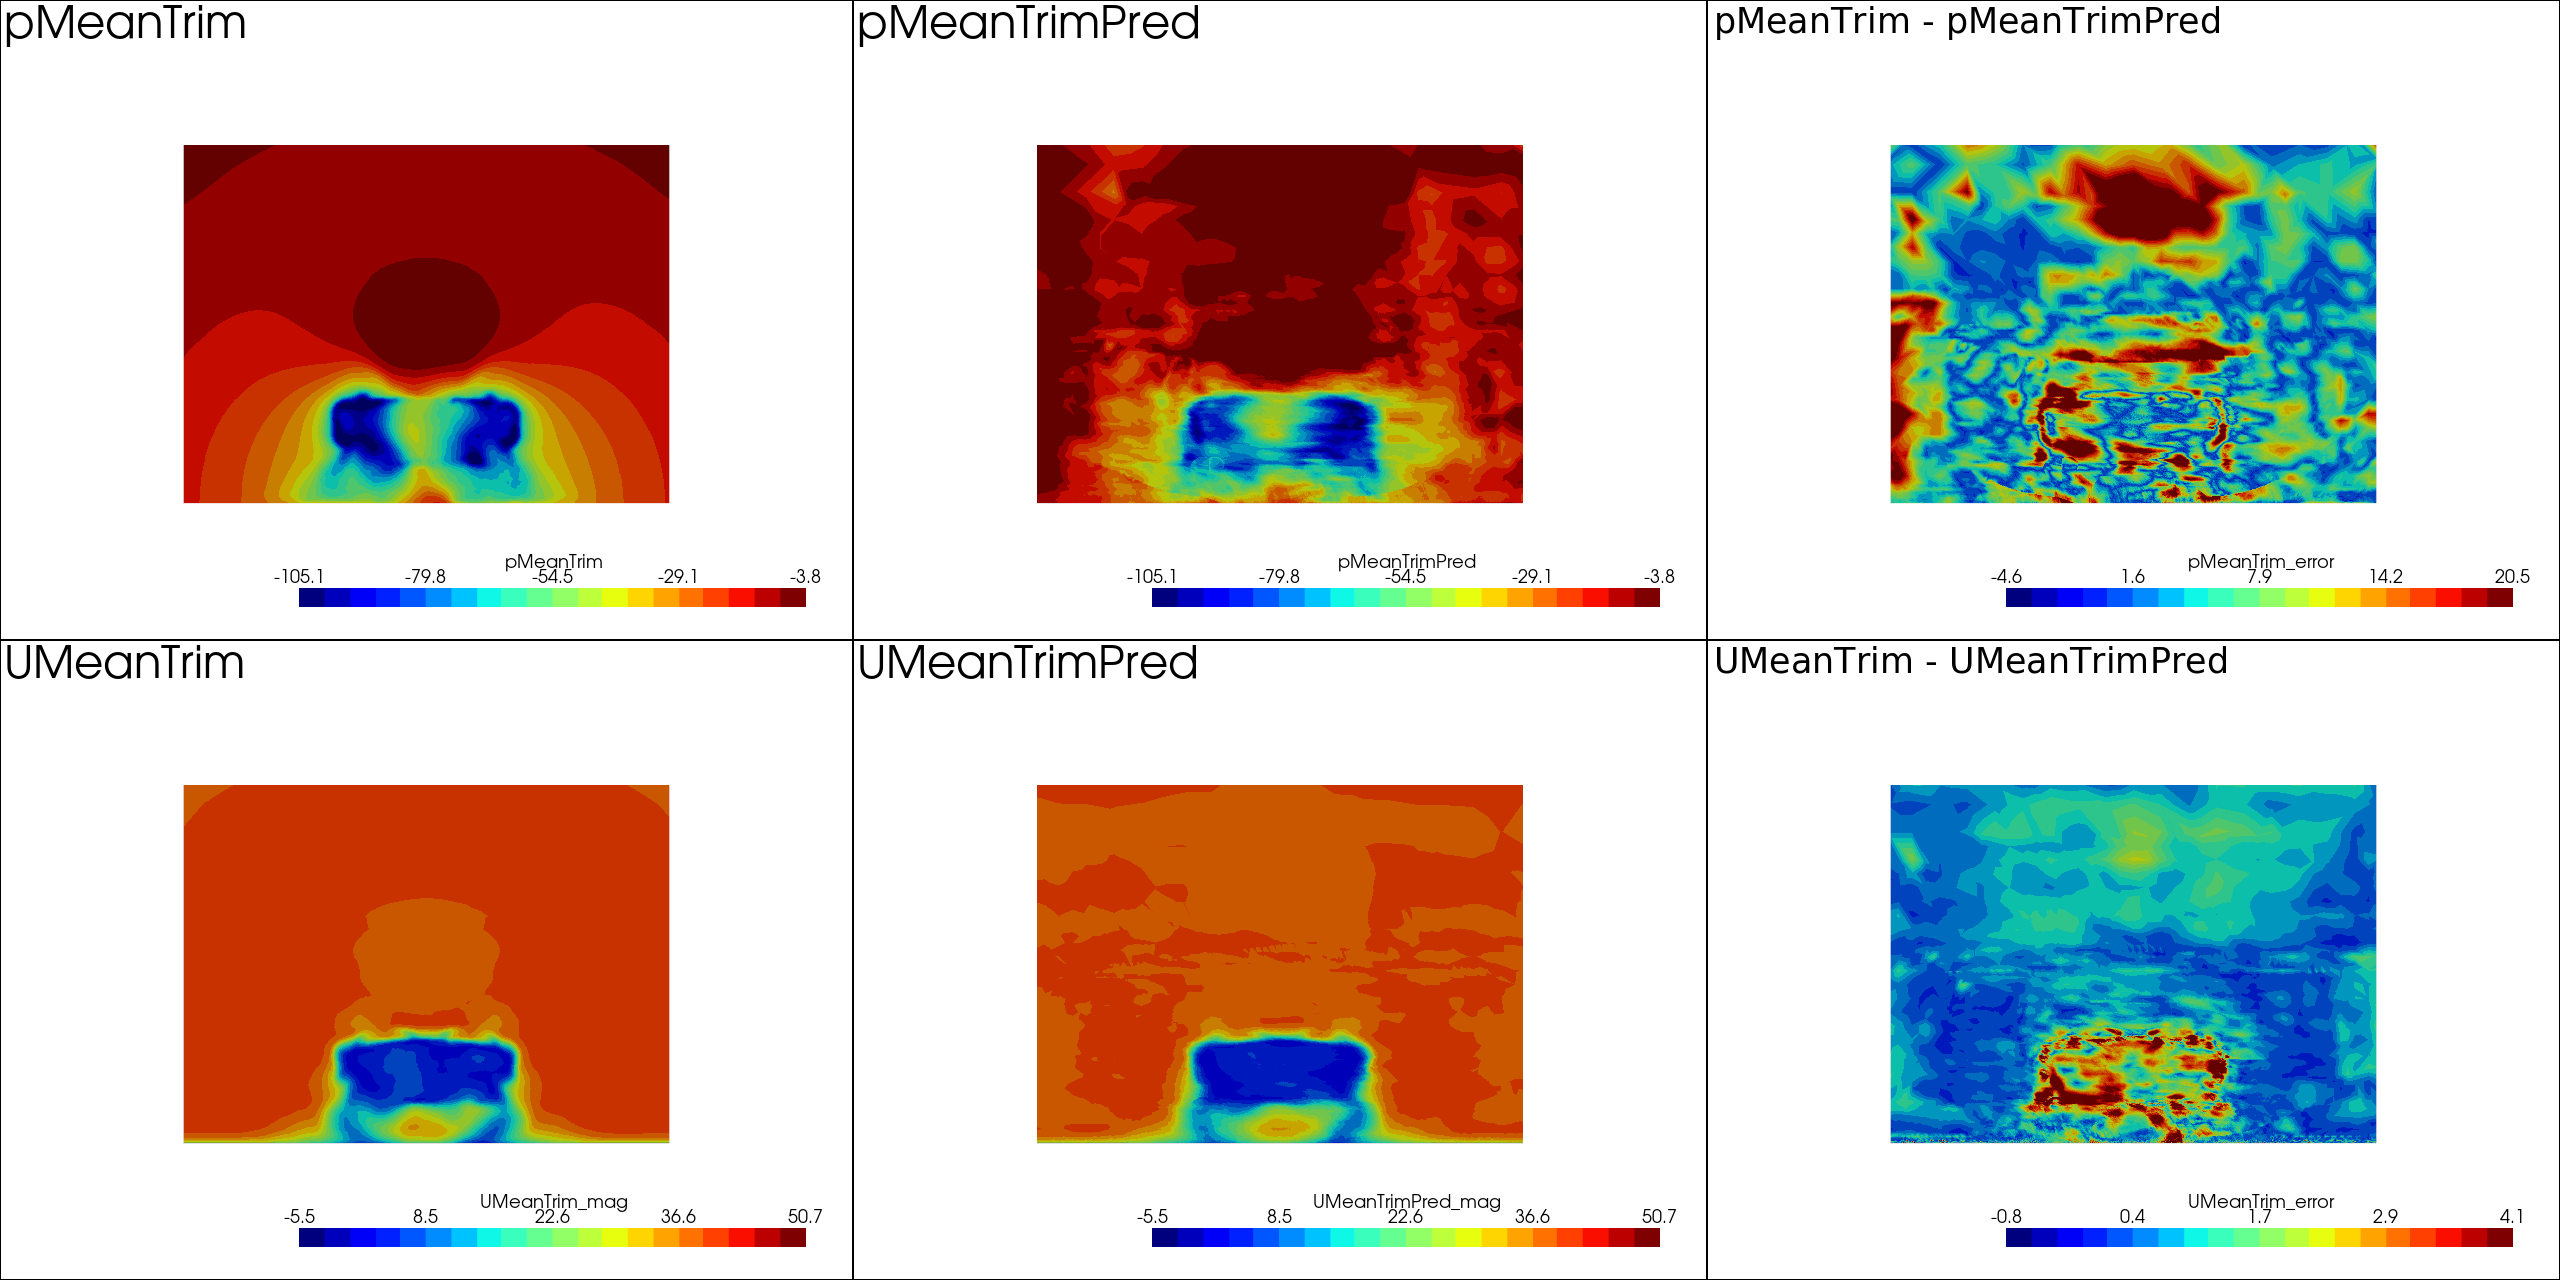

In [9]:
plotter = plot_field_comparisons(
    x_4_slice,
    true_fields=["pMeanTrim", "UMeanTrim"],
    pred_fields=["pMeanTrimPred", "UMeanTrimPred"],
    plot_vector_components=False,
    view="yz",
    dtype="point",
    cmap="jet",
    lut=20,
    window_size=[2560, 1280],
)

plotter.screenshot("./sample_202_volume_x_4_slice_comparison.png")

# Display the image
from IPython.display import Image

Image(filename="./sample_202_volume_x_4_slice_comparison.png")

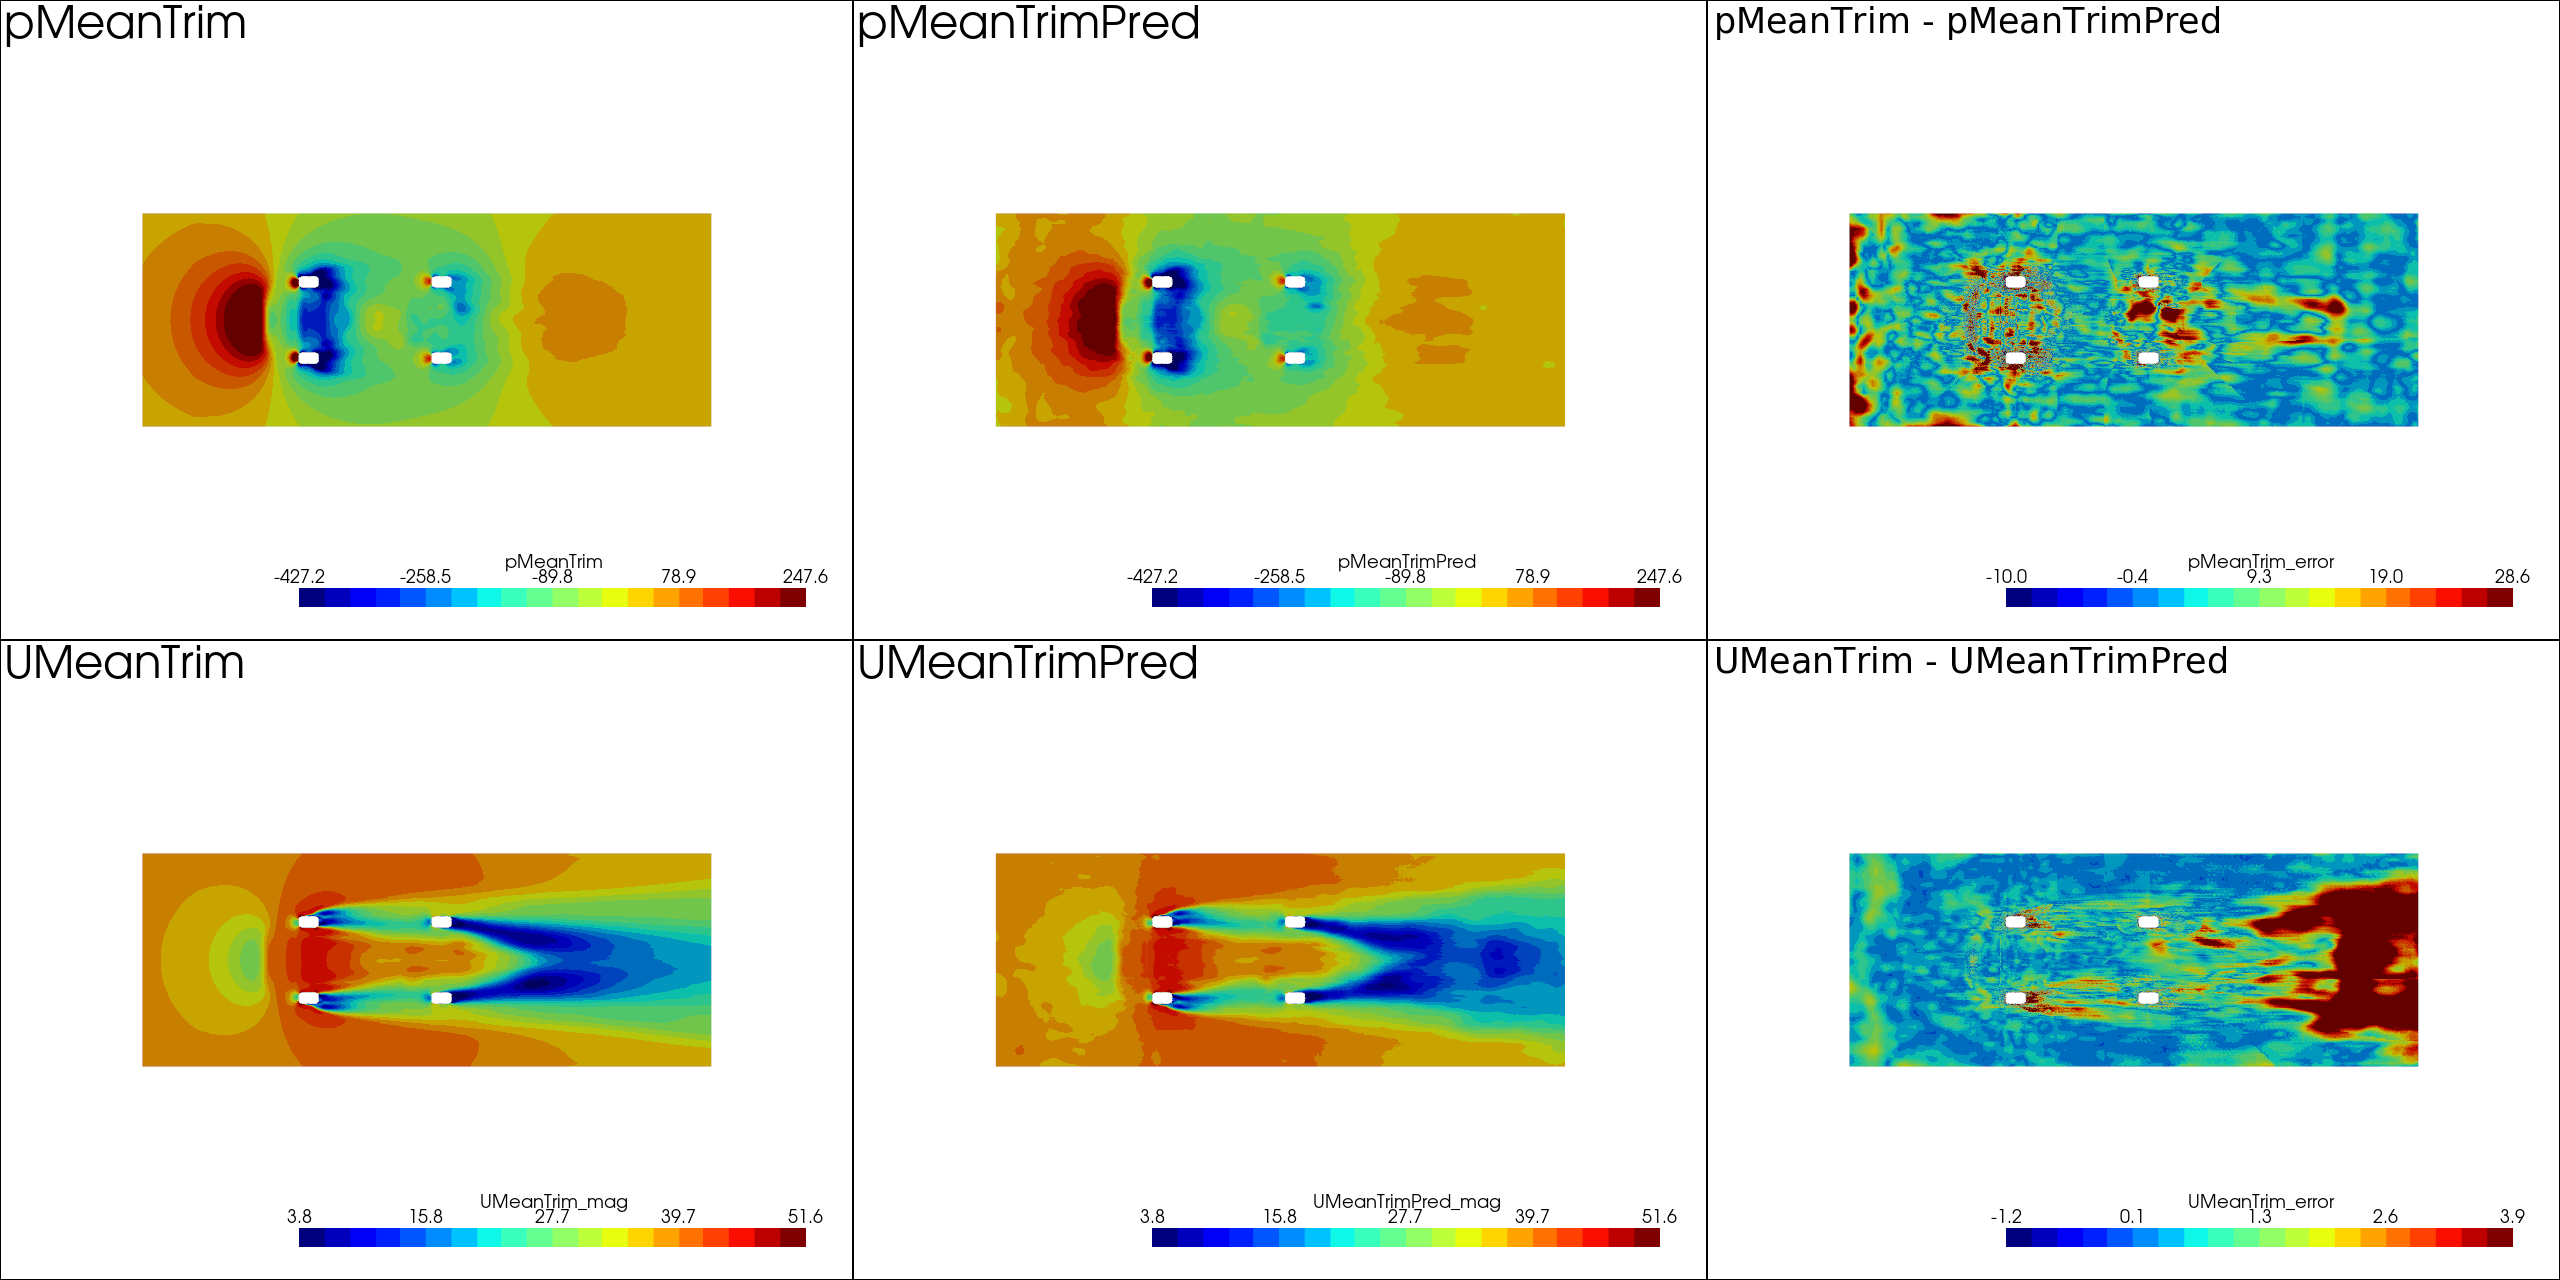

In [10]:
plotter = plot_field_comparisons(
    z_neg_0_2376_slice,
    true_fields=["pMeanTrim", "UMeanTrim"],
    pred_fields=["pMeanTrimPred", "UMeanTrimPred"],
    plot_vector_components=False,
    view="xy",
    dtype="point",
    cmap="jet",
    lut=20,
    window_size=[2560, 1280],
)

plotter.screenshot("./sample_202_volume_z_slice_comparison.png")

# Display the image
from IPython.display import Image

Image(filename="./sample_202_volume_z_slice_comparison.png")

Slice visualizations show that the AI prediction captures the larger structures in the flow field.

Such visualizations do not reveal how predictions look across the entire validation dataset. For that, one can project errors from different samples onto fixed points and build aggregate visualizations. The [`../generate_volume_benchmarks.py`](../generate_volume_benchmarks.py) script provides this capability.

Below we show the error distribution across the entire DrivAerML validation set (visualized using sample ID 439, the largest STL by geometric size).

![Aggregate Errors](img/resampled_volume_errors.png)

Overall, errors are typically higher in the wake for velocity, closer to the car surface for pressure, and in the farfield for turbulent viscosity.

Such analysis is especially useful when geometric differences between samples are modest (e.g., DrivAerML), where resampling techniques enable meaningful aggregate visualizations.

Let's also create line plots for more detailed visualization. Here, we visualize the wake behind the wheels and the flow along the centerline under the car, similar to the results presented in the [DrivAerML paper](https://arxiv.org/abs/2408.11969). 

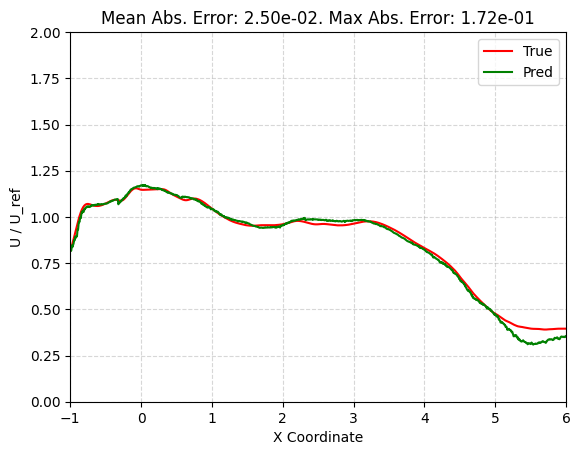

In [11]:
from physicsnemo.cfd.postprocessing_tools.visualization.utils import plot_line

centerline_bottom = y_slice.slice(normal="z", origin=(0, 0, -0.2376))

fig = plot_line(
    centerline_bottom,
    plot_coord="x",
    field_true="UMeanTrim",
    field_pred="UMeanTrimPred",
    normalize_factor=38.889,
    coord_trim=(-1.0, 6.0),
    field_trim=(0, 2.0),
    flip=False,
    true_line_kwargs={"color": "red", "label": "True"},
    pred_line_kwargs={"color": "green", "label": "Pred"},
    xlabel="X Coordinate",
    ylabel="U / U_ref",
)

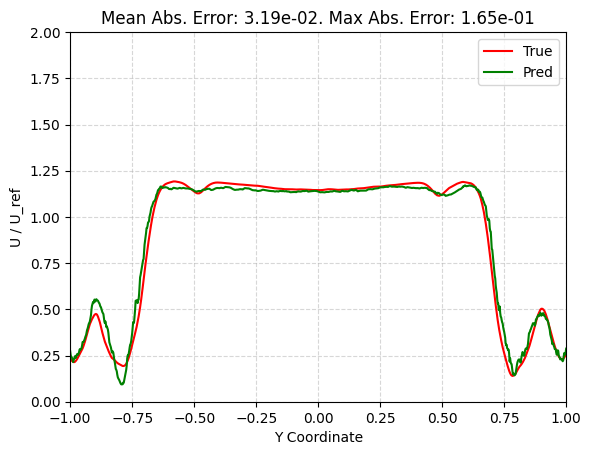

In [12]:
front_wheel_wake = z_neg_0_2376_slice.slice(normal="x", origin=(0.35, 0, 0))

fig = plot_line(
    front_wheel_wake,
    plot_coord="y",
    field_true="UMeanTrim",
    field_pred="UMeanTrimPred",
    normalize_factor=38.889,
    coord_trim=(-1.0, 1.0),
    field_trim=(0, 2.0),
    flip=False,
    true_line_kwargs={"color": "red", "label": "True"},
    pred_line_kwargs={"color": "green", "label": "Pred"},
    xlabel="Y Coordinate",
    ylabel="U / U_ref",
)

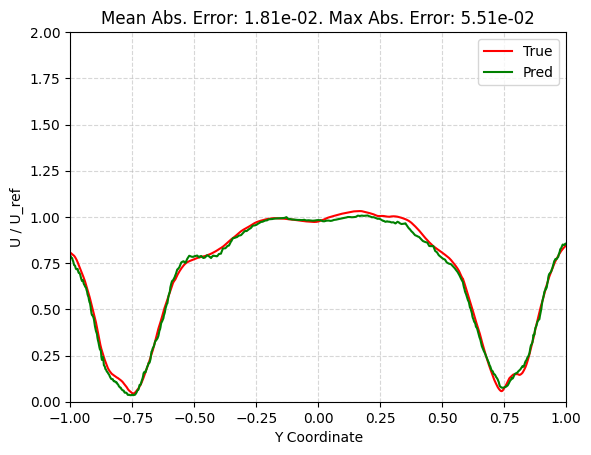

In [13]:
rear_wheel_wake = z_neg_0_2376_slice.slice(normal="x", origin=(3.15, 0, 0))

fig = plot_line(
    rear_wheel_wake,
    plot_coord="y",
    field_true="UMeanTrim",
    field_pred="UMeanTrimPred",
    normalize_factor=38.889,
    coord_trim=(-1.0, 1.0),
    field_trim=(0, 2.0),
    flip=False,
    true_line_kwargs={"color": "red", "label": "True"},
    pred_line_kwargs={"color": "green", "label": "Pred"},
    xlabel="Y Coordinate",
    ylabel="U / U_ref",
)

Generally, the line plots show good correlation between the AI model results and the ground truth. However, the model struggles to capture wake behavior.

That completes the volume benchmarking notebook. For surface benchmarking, see [`surface_benchmarking.ipynb`](./surface_benchmarking.ipynb). To run these metrics across multiple geometries or cases, refer to [`../generate_volume_benchmarks.py`](../generate_volume_benchmarks.py).

## Bonus: Computing the Equation Residuals

Continuity and the Momentum Equations (Navier-Stokes) are the fundamental equations that govern the fluid dynamics of the external aero. We can use the library to measure how well the model's results capture the mass and energy balances. We can use the `compute_continuity_residuals` and `compute_momentum_residuals` functions for these.

---
**NOTE**

Due the the large size of the mesh, this computation can take a few minutes. If you are not interested in the this metric, you can skip the below code blocks. 

---

In [14]:
from physicsnemo.cfd.postprocessing_tools.metrics.physics import (
    compute_continuity_residuals,
    compute_momentum_residuals,
)

# Let's clip the mesh to work on a smaller dataset
# Set crinkle=True for faster clipping
clipped_mesh = mesh.clip_box(
    bounds=[-2, 6, -0.20, 0.20, -0.32, 3.00],
    invert=False,
    progress_bar=True,
    merge_points=False,
    crinkle=True,
)

# Compute continuity
clipped_mesh = compute_continuity_residuals(
    clipped_mesh,
    true_velocity_field="UMeanTrim",
    predicted_velocity_field="UMeanTrimPred",
)

# Optionally, compute momentum using RANS equations
nu = 1.507e-5
rho = 1.0
clipped_mesh = compute_momentum_residuals(
    clipped_mesh,
    true_velocity_field="UMeanTrim",
    predicted_velocity_field="UMeanTrimPred",
    true_pressure_field="pMeanTrim",
    predicted_pressure_field="pMeanTrimPred",
    true_nu_field="nutMeanTrim",
    predicted_nu_field="nutMeanTrimPred",
    nu=nu,
    rho=rho,
)


  0%|          [00:00<?]


Clipping a Dataset by a Bounding Box:   0%|          [00:00<?]


Clipping a Dataset by a Bounding Box:   5%|▌         [00:08<02:35]


Clipping a Dataset by a Bounding Box:  10%|█         [00:16<02:27]


Clipping a Dataset by a Bounding Box:  15%|█▌        [00:28<02:52]

...


Clipping a Dataset by a Bounding Box:  95%|█████████▌[03:31<00:09]


Clipping a Dataset by a Bounding Box: 100%|██████████[03:39<00:00]


Clipping a Dataset by a Bounding Box: 100%|██████████[03:39<00:00]


Clipping a Dataset by a Bounding Box: 100%|██████████[03:39<00:00]

/workspace/aero-benchmarking/physicsnemo-cfd/physicsnemo/cfd/postprocessing_tools/metrics/physics.py:210: PyVistaDeprecationWarning: Parameter 'use_all_points' is deprecated since VTK < 9.2 is no longer supported. This parameter has no effect and is always `True`.
  edge_mesh = mesh.extract_all_edges(use_all_points=True, clear_data=True)


Note that the above two functions will create additional fields for `Continuity`, `ContinuityPred`, `Momentum` and `MomentumPred`. The resulting mesh files can be processed as before. For the purposes of this notebook, let's plot the the fields along the mid-y slice. 

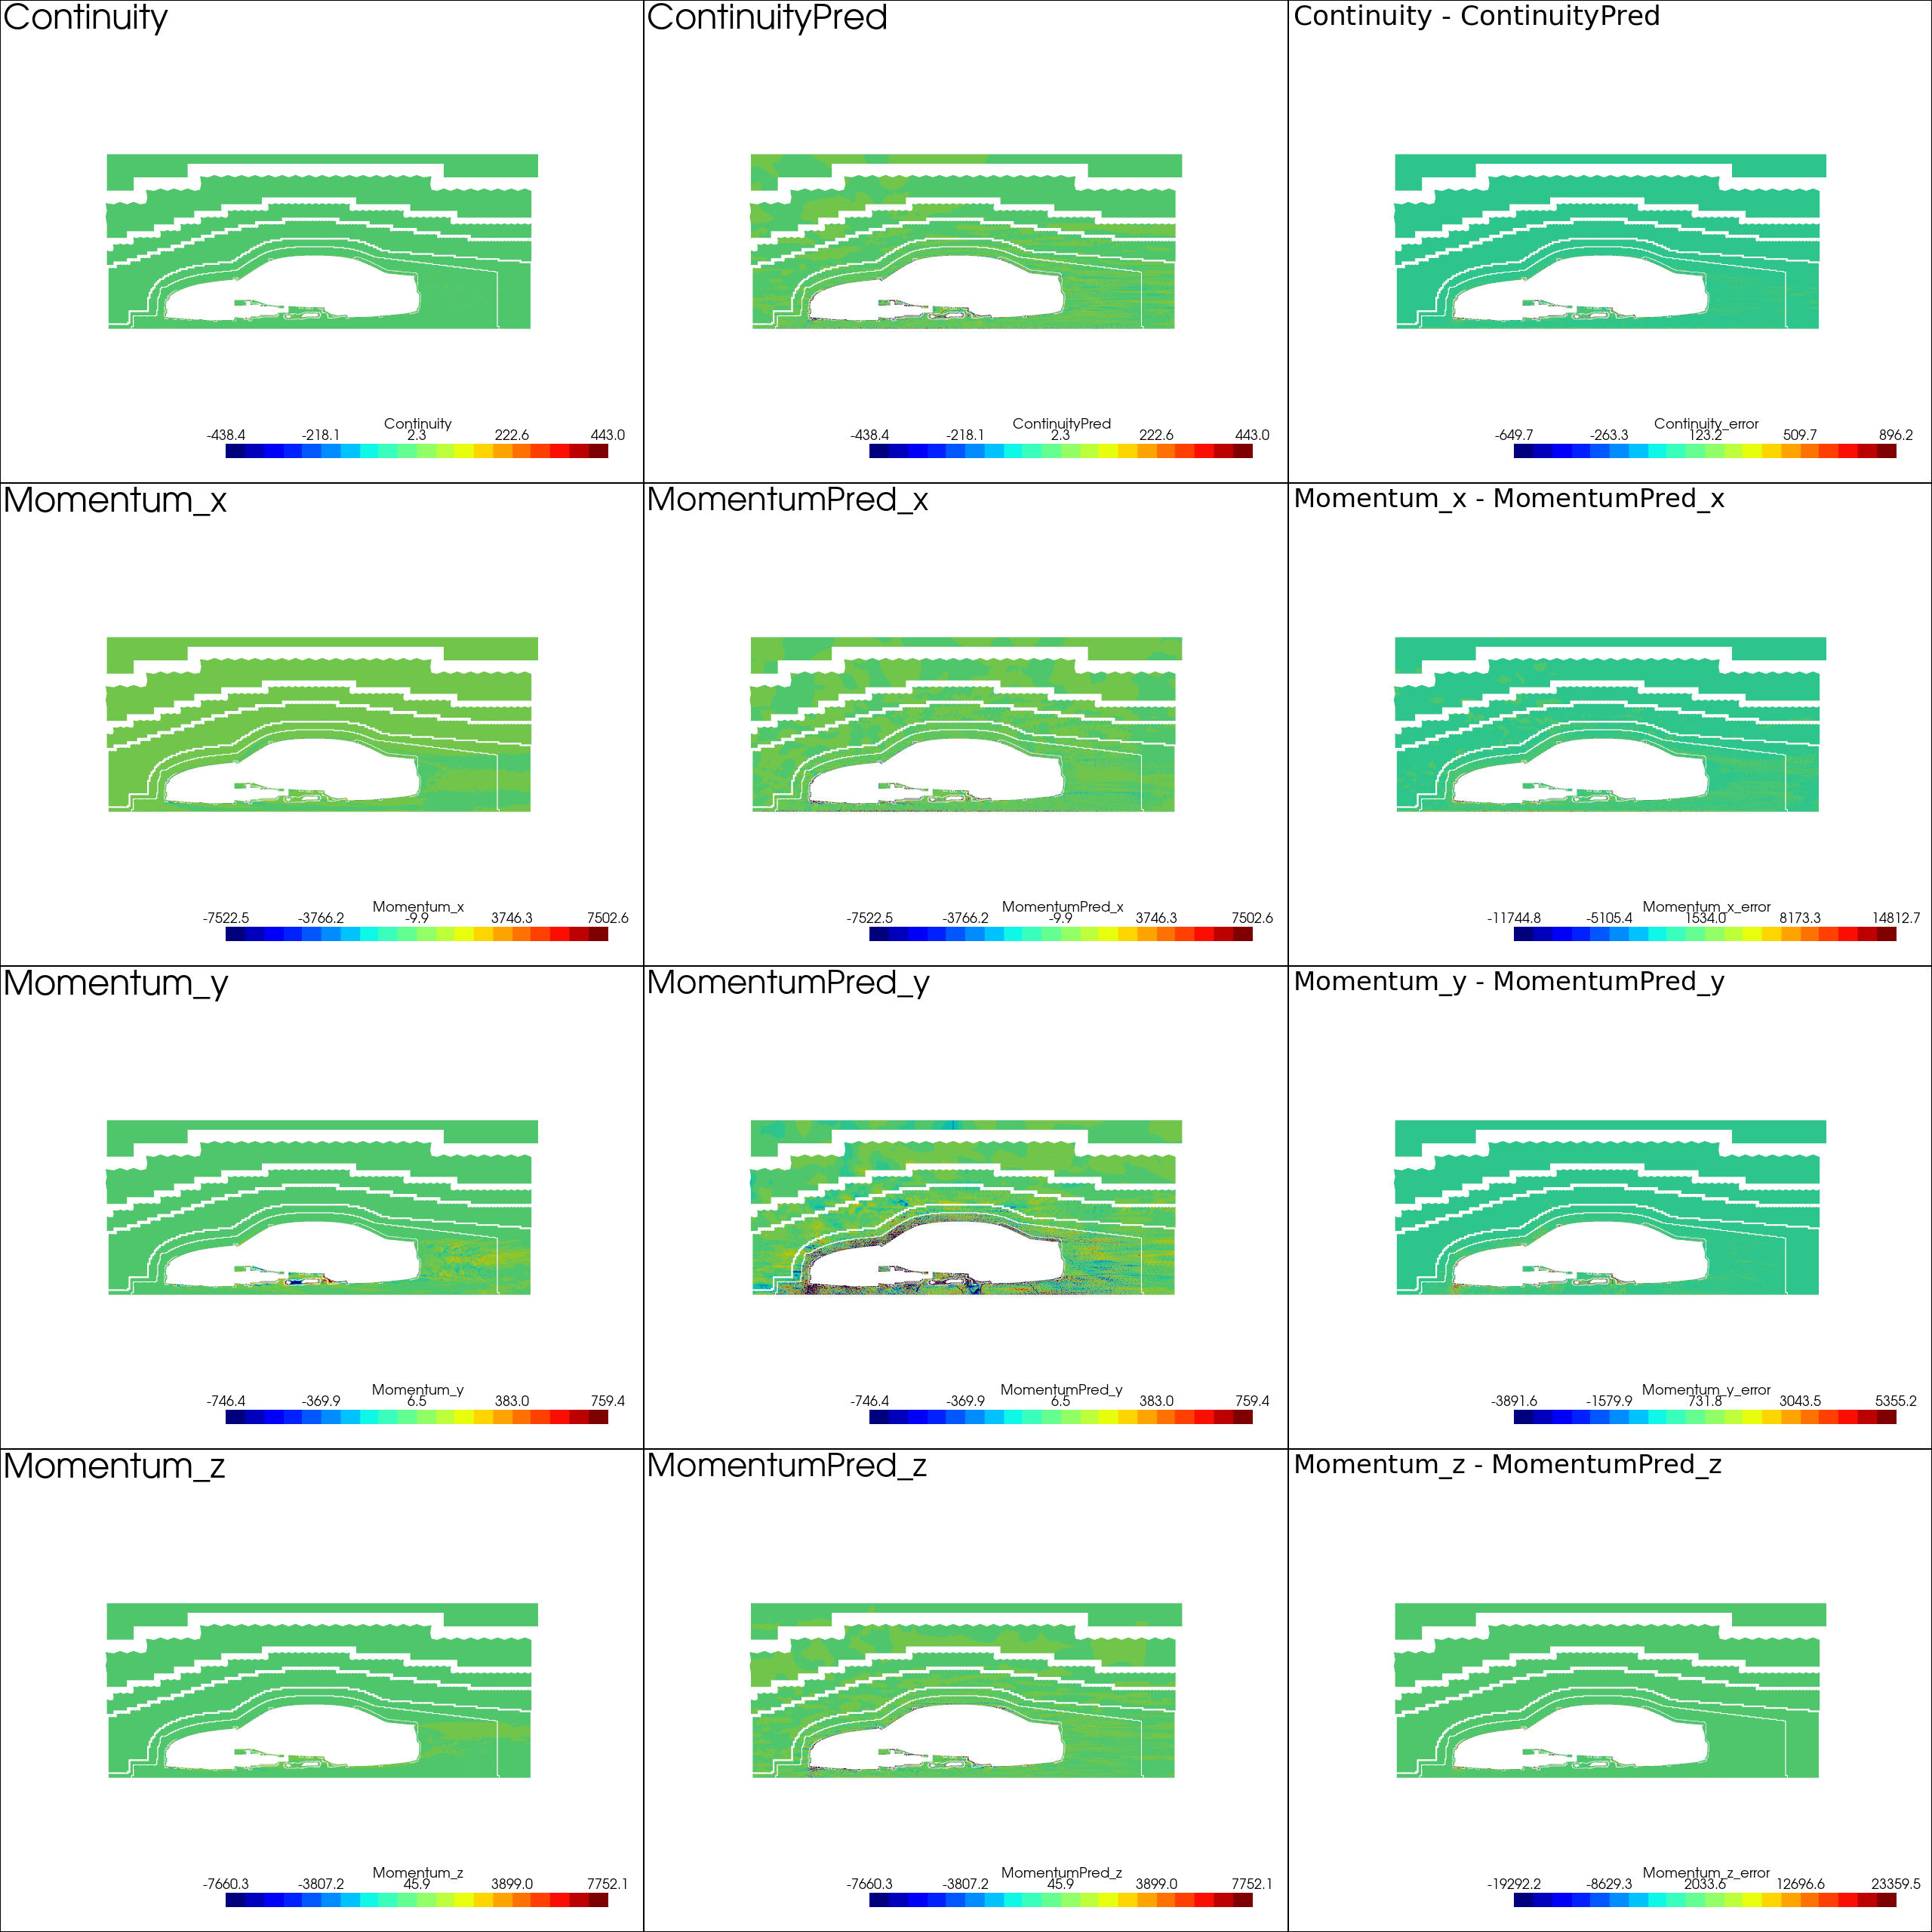

In [15]:
y_slice = clipped_mesh.slice(normal="y", origin=(0, 0, 0))
y_slice = y_slice.clip_box(bounds, invert=False)

plotter = plot_field_comparisons(
    y_slice,
    true_fields=["Continuity", "Momentum"],
    pred_fields=["ContinuityPred", "MomentumPred"],
    plot_vector_components=True,
    view="xz",
    dtype="point",
    cmap="jet",
    lut=20,
    window_size=[2560, 2560],
)

plotter.screenshot("./sample_202_volume_y_slice_residuals_comparison.png")

# Display the image
from IPython.display import Image

Image(filename="./sample_202_volume_y_slice_residuals_comparison.png")

The predicted residuals show good adherence of the model predictions to the governing laws. The residuals are generally seen to be higher in the wake area or the areas of high shear.

We can also compute the residuals in an integral sense. For example, below code demonstrates integral continuity computed on a box surrounding the car.

In [16]:
from physicsnemo.metrics.cae.integral import surface_integral
from physicsnemo.cfd.postprocessing_tools.interpolation.interpolate_mesh_to_pc import interpolate_mesh_to_pc

# Define a box smaller than the overall bounding box
integral_box_bounds = [-2, 5, -1.5, 1.5, -0.2, 1.5]
integral_box = pv.Box(integral_box_bounds, level=40)
integral_box = interpolate_mesh_to_pc(integral_box, mesh, ["UMeanTrim", "UMeanTrimPred"], mesh_dtype="point")

integrals = surface_integral(integral_box)
integrals

{'integral_UMeanTrim': array([-1.41115921]),
 'integral_UMeanTrimPred': array([-3.78166219]),
 'integral_Normals': array([75.99999984])}

 We can observe that the integral continuity (integral U) for the predicted result is further away from 0 compared to the true result. It is quite interesting however to note that even the true solution does not respect the continuity perfectly. 